# Lab 08: Vision Transformers and VLMs, Talking to Your Images

**ITAI 1378  |  Module 08 Companion Lab  |  2026**

**Author:** Patricia McManus     **Collaborator:** Claude (Anthropic)

**Course:** AI and Robotics Program, Digital and Information Technology Center of Excellence, Houston City College

---

In Module 08 you learned how Vision Transformers chop an image into patches and treat them like words, and how Vision Language Models (VLMs) connect a model's eyes to a language model so it can describe, answer, and reason about images. The frontier VLMs you studied (GPT-5.5, Claude Opus 4.7, the Gemini 3 family) cost money per image. Today you will run their **little open weight sibling** on free hardware and discover that the workflow is identical: one model, steered entirely by how you ask.

**By the end of this lab you will be able to:**

1. Visualize how a Vision Transformer "reads" an image as patches
2. Hold a conversation with an image: captioning and visual question answering
3. Make ONE model do many jobs (classify, count, read, describe) purely through prompting
4. Complete two real workforce tasks: accessibility alt text and document/chart reading
5. Audit a VLM's reliability and catch it hallucinating
6. Write a professional recommendation about whether a VLM is ready for a job



## How This Lab Works

* Cells marked **RUN AS IS** are complete. Run them and read the comments.
* Cells marked **YOUR CODE HERE** have a TODO for you to complete. Tips are in the comments.
* Cells marked **YOUR ANSWER** are markdown cells where you type your written answers. Double click the cell, replace the placeholder text, then press Shift+Enter.
* **YOUR TURN** sections are graded checkpoints. **Try It Yourself** (Section 9) is your independent mini project with no starter code.

### Your GPU Budget (read this!)

This lab is even lighter than Lab 07:

* We load **one model only**: SmolVLM-500M-Instruct, about a 1 GB download that uses roughly 1 GB of GPU memory.
* Each question you ask takes a few seconds. The whole lab needs a few dozen questions.
* The CPU fallback is genuinely usable this time. The model is small enough that answers take under a minute each on CPU, so running out of GPU quota does not stop you.
* Plan to finish in one sitting so the downloaded model stays cached.

**Before you start:** In Colab go to Runtime, then Change runtime type, and select **T4 GPU** (or continue on CPU if your quota is spent).

## Grading Rubric (100 points, bonus available)

**Implementation, 60 points (six items, 10 points each)**

| Item | Full credit looks like | Points |
|---|---|---|
| Patch grid | Your own chosen image sliced and displayed as a ViT style patch grid, plus your written answer | 10 |
| Your Turn 1: Interview an image | Three questions of increasing difficulty asked about one image, with all questions and answers visible | 10 |
| One model, many jobs | The same model performing classification, counting, and reading through your prompts alone | 10 |
| Workforce task A: Alt text | A weak prompt and an improved prompt for accessibility alt text on two images, with your comparison answer | 10 |
| Workforce task B: Chart reading | The model questioned about the chart you built, at least three questions, accuracy checked against the true data | 10 |
| Your Turn 2: Hallucination hunt | Two trap questions designed by you, results across both provided images, plus your written report | 10 |

**Analysis, 40 points**

| Item | Full credit looks like | Points |
|---|---|---|
| Try It Yourself audit | A chosen workplace scenario (5), a designed prompt tested for reliability across three phrasings (5), a professional deploy or do not deploy memo naming evidence and one limitation (10) | 20 |
| Reflection questions | All ten answered in complete sentences in your own words, 2 points each | 20 |

**Bonus, up to 20 points:** see Section 11.

**Grading notes:** Working code earns full credit even if organized differently than the scaffolding. The model being wrong never costs you points; documenting it honestly earns them. What is graded is your process and your judgment. There is no deduction for late submission.

**Academic integrity:** Written answers must be your own words. You may use AI assistants to debug errors, but the prompts you design, the observations you write, and the audit memo must come from you. Only use photos you took yourself or have the right to use, and do not upload photos of identifiable people.

**Submission:** This notebook is the only deliverable. Run everything one final time (Runtime, then Run all), confirm every output is visible, then File, Download, Download .ipynb **with all outputs visible**. Name it **L08_LastName_FirstName_ITAI1378.ipynb** and submit to Canvas.

## Section 1: Setup

**RUN AS IS.** We install the Hugging Face libraries and detect your hardware. Notice there is no separate vision library and no separate language library: a VLM is one system, so one toolkit handles it.

In [1]:
# RUN AS IS
!pip install -q "transformers<5.0.0" accelerate

import torch

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.float16
    print("GPU ready:", torch.cuda.get_device_name(0))
else:
    DEVICE = "cpu"
    DTYPE = torch.float32
    print("CPU fallback active. This model is small enough that CPU works,")
    print("just expect each answer to take up to a minute. Be patient!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 10.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.
GPU ready: Tesla T4


## Section 2: Seeing Like a Vision Transformer (Zero GPU Cost)

Before we talk to a VLM, let's see what its eyes actually receive. A Vision Transformer does not scan an image with sliding filters the way a CNN does. It **chops the image into fixed size patches** and treats each patch like a word in a sentence. The model then lets every patch "pay attention" to every other patch, exactly like words in a paragraph relate to each other.

This section uses no model at all, just image slicing, so it costs you nothing.

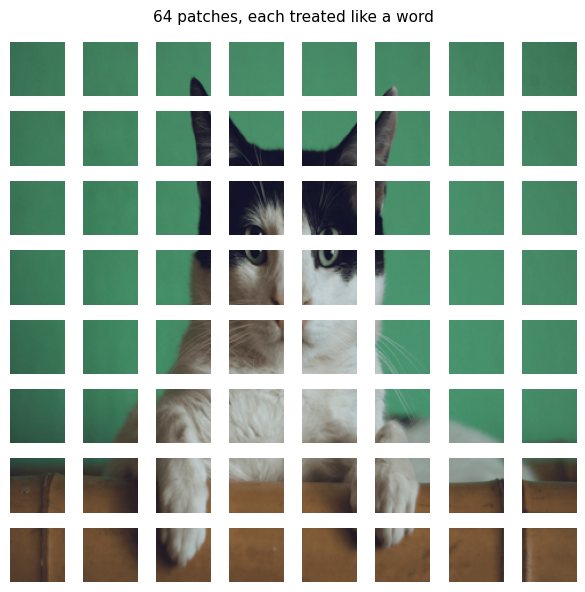

In [3]:
# RUN AS IS
# Download a sample image and slice it into a ViT style patch grid.
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt

url = "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/diffusers/cat.png"
urllib.request.urlretrieve(url, "sample_cat.png")
img = Image.open("sample_cat.png").convert("RGB").resize((384, 384))

def show_patches(image, patch_size=48):
    """Slice an image into square patches and display them as a spaced grid,
    the way a Vision Transformer sees its input."""
    w, h = image.size
    cols, rows = w // patch_size, h // patch_size
    fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
    for r in range(rows):
        for c in range(cols):
            patch = image.crop((c * patch_size, r * patch_size,
                                (c + 1) * patch_size, (r + 1) * patch_size))
            axes[r, c].imshow(patch)
            axes[r, c].axis("off")
    fig.suptitle(f"{rows * cols} patches, each treated like a word", fontsize=11)
    plt.tight_layout()
    plt.show()

show_patches(img)

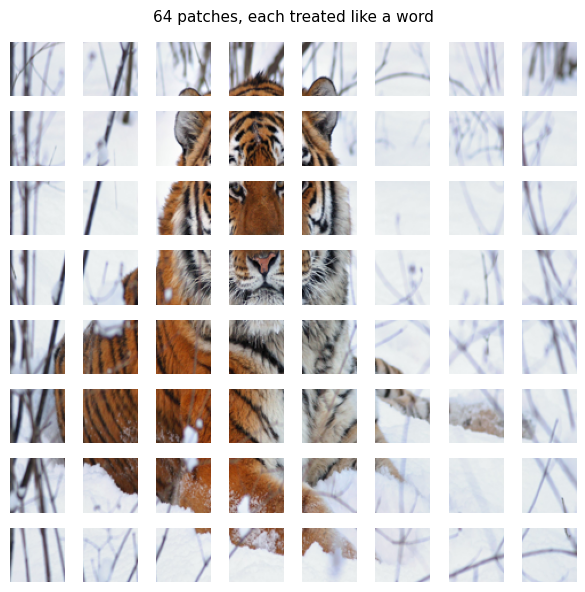

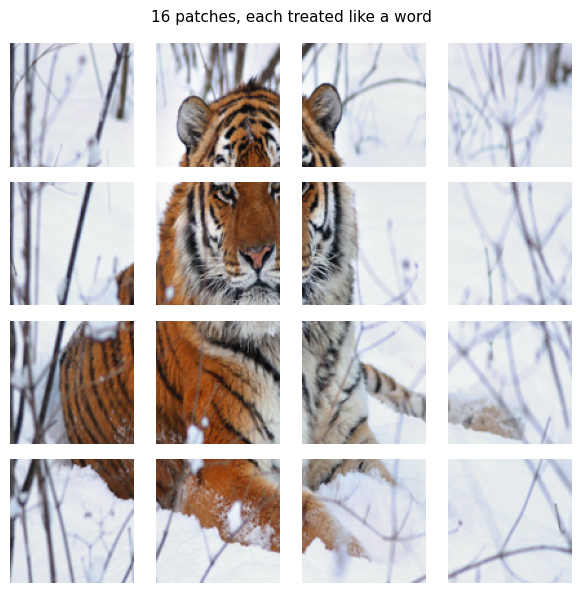

In [4]:
import urllib.request
from PIL import Image
import matplotlib.pyplot as plt

url = "https://media.cnn.com/api/v1/images/stellar/prod/200605082916-01-real-tiger-king-siberian.jpg?q=w_3072,h_2048,x_0,y_0,c_fill"
urllib.request.urlretrieve(url, "/content/Amur_Tiger.jpg")
img = Image.open("/content/Amur_Tiger.jpg").convert("RGB").resize((384, 384))
show_patches(img, patch_size=48)
show_patches(img, patch_size=96)
# TODO: load a DIFFERENT image (upload your own with the Colab folder icon,
#       or reuse a different URL) and display its patch grid at TWO patch
#       sizes: 48 and 96.
# Tip: resize to (384, 384) first so the grid divides evenly.
# Tip: img2 = Image.open("/content/yourfile.jpg").convert("RGB").resize((384, 384))
#      then call show_patches(img2, patch_size=48) and again with 96. /content/Amur_Tiger.jpg

### YOUR ANSWER (Patches)

*Double click and replace: With 48 pixel patches versus 96 pixel patches, which grid would give the model a more detailed "sentence" to read, and what is the tradeoff? Answer in two or three sentences using the words of an image analogy.*

## Section 3: Load the VLM and Have Your First Conversation

**RUN AS IS.** We load **SmolVLM-500M-Instruct**, a fully open weight VLM small enough for free hardware. Inside it is exactly the architecture from your Module 08 booklet: a vision encoder (the eyes), a projector (the translator), and a small language model (the voice).

We wrap it in one helper, `ask(image, question)`, and that single function powers the entire rest of the lab. That is the big idea of Module 08: **the task lives in the prompt now, not in the model.**

In [5]:
# RUN AS IS
from transformers import AutoProcessor, AutoModelForVision2Seq

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForVision2Seq.from_pretrained(MODEL_ID, torch_dtype=DTYPE).to(DEVICE)

def ask(image, question, max_new_tokens=150):
    """Ask the VLM one question about one image and return its answer."""
    messages = [{"role": "user",
                 "content": [{"type": "image"},
                             {"type": "text", "text": question}]}]
    prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
    inputs = processor(text=prompt, images=[image], return_tensors="pt").to(DEVICE)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens)
    answer = processor.batch_decode(out, skip_special_tokens=True)[0]
    # The decoded text contains the whole conversation; keep only the reply.
    return answer.split("Assistant:")[-1].strip()

print("VLM loaded. Say hello:")
print(ask(img, "Describe this image in one sentence."))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

VLM loaded. Say hello:
In this image we can see a tiger laying on the snow. Behind the tiger there are some trees.


### YOUR TURN 1: Interview an Image (Graded, 10 pts)

Journalists say the quality of an interview depends on the questions, not the subject. Same here. Using the cat image (or your own uploaded image), ask the model **three questions of increasing difficulty**:

1. An easy factual question (what is in the image)
2. A detail question (color, position, count, background)
3. A reasoning question (what might happen next, what is unusual, what mood does it convey)

Print each question with its answer so both are visible in your output.

In [6]:
# YOUR CODE HERE (Your Turn 1)

# TODO: write your three questions and ask them.
# Tip: a loop keeps this readable:
# for q in [question_1, question_2, question_3]:
#     print("Q:", q)
#     print("A:", ask(img, q))
#     print()

question_1 = "What animal is in this image?"
question_2 = "What color is the snow?"
question_3 = "What could this animal be looking at?"

for q in [question_1, question_2, question_3]:
    print("Q:", q)
    print("A:", ask(img, q))
    print()

Q: What animal is in this image?
A: There is a tiger in this image.

Q: What color is the snow?
A: The snow is white in color.

Q: What could this animal be looking at?
A: The animal is looking at the camera.



### YOUR ANSWER (Your Turn 1)

*The weakest answer out of all is probably the last question. Main reason is because The Tiger might be looking past the camera, at the cameraman.*

## Section 4: One Model, Many Jobs (Graded, 10 pts)

Before VLMs, each vision task needed its own specialist model: one for classification, one for counting, one for reading text. A VLM replaces the whole shelf, because **the prompt selects the job**. Watch the demo, then make the model switch jobs yourself.

**Prompting tip that professionals rely on:** constrain the output format. "Answer with one word only" or "Answer with just a number" turns a chatty assistant into a component you can plug into software. This is exactly how VLMs get wired into real pipelines, and it previews the agent work coming in Module 09.

In [7]:
# RUN AS IS
# Job 1, classification: the prompt turns the VLM into a classifier.
print("Classifier:", ask(img, "Is this a cat, a dog, or a bird? Answer with one word only."))

Classifier: Cat.


In [8]:
# YOUR CODE HERE (Job switching)

# TODO: make the SAME model do two more jobs on the same image:
#   Job 2, counter: ask how many of something there are, demanding just a number.
#   Job 3, reader/describer: ask it to list every object it can see, one per line.
# Tip: the only thing you are allowed to change is the question string.
#      That is the whole point of this section.

# TODO: Job 2 here
print("Classifier:", ask(img, "Describe the three main colors of the Tiger."))
# TODO: Job 3 here
print("Classifier:", ask(img, "List every object you can see."))

Classifier: The tiger is primarily orange with black stripes.
Classifier: The image features a tiger in a snowy environment. The tiger is the central focus of the image and is lying down in the snow. The tiger has a striking orange and black coat with distinctive black stripes, which are typical of tiger species. The fur on its body is well-groomed and appears to be healthy. The tiger's eyes are a deep, piercing blue, which is a characteristic feature of many tiger species.

The tiger is lying down in the snow, which is a common behavior for animals in cold environments. The snow is white and pristine, indicating that it has recently fallen. The tiger's body is partially covered in snow, which suggests that it has been in the snow for some time.

In the background


### YOUR ANSWER (One model, many jobs)

*The main thing YOLO still has the advantage over VLM is the ability to detect smaller details. For example, if my image of a tiger had a leaf, YOLO would be able to detect it compared to VLM. The advantage of VLM has over is the ability of describing what's in the image instead of just saying what and where is an object in a image.*

## Section 5: Workforce Task A, Accessibility Alt Text (Graded, 10 pts)

Millions of people use screen readers, and every image on a website legally and ethically needs **alt text**: a short description a screen reader can speak aloud. Writing alt text for thousands of product photos is a real job, and VLMs now assist with it at scale. But quality depends entirely on the prompt.

Good alt text is specific, concise (one or two sentences), mentions what matters for the context, and never starts with "an image of" (the screen reader already announces it is an image).

Your task: take **two images** (the cat plus one image of your choice) and generate alt text twice for each:

1. First with a **weak prompt**: just "Describe this image."
2. Then with a **professional prompt you write** that encodes the rules above.

In [9]:
# YOUR CODE HERE (Workforce task A)

# TODO: write your professional alt text prompt. Encode the rules:
#       concise, specific, useful for a shopper or reader, never "an image of".
# Tip: you can put instructions AND constraints in one question, for example:
#      "Write alt text for this image for a screen reader user. One sentence,
#       specific, do not begin with the words an image of."

weak_prompt = "Describe this image."
pro_prompt = "Describe how the animal is lying down in the snow and its body position."

img2 = Image.open("/content/Snow_Leopard.jpg").convert("RGB").resize((384, 384))

images = {"Amur Tiger": img, "Snow_Leopard.jpg": img2}
prompts = {"Weak": weak_prompt, "Professional": pro_prompt}


for img_name, image in images.items():
    for prompt_name, prompt in prompts.items():
        print(f"{img_name} — {prompt_name} prompt:")
        print(ask(image, prompt))
        print()
# TODO: run both prompts on BOTH images and print all four results, clearly
#       labeled so the improvement is easy to see.

Amur Tiger — Weak prompt:
The image depicts a tiger in a snowy environment. The tiger is the central focus of the image, lying down in the snow. The tiger is a large, majestic animal with a distinctive orange and black coat, characterized by its distinctive stripes. The fur on its body is short and appears well-groomed. The tiger's face is prominently visible, with its eyes looking directly at the camera. The tiger's expression is calm and serene, with a gentle expression that suggests it is relaxed and comfortable in its surroundings.

The tiger is lying on a snow-covered surface, which appears to be a snowbank or a similar elevated area. The snow is thick and covers the ground, indicating that the tiger is in a relatively undisturbed area.

Amur Tiger — Professional prompt:
The tiger is lying down in the snow.

Snow_Leopard.jpg — Weak prompt:
The image depicts a snow leopard, a majestic feline species native to the mountains of Central Asia. The snow leopard is the world's rarest and

### YOUR ANSWER (Alt text)

What Improved from both the weak and professional prompts is that the detail of both were greater compared to previous questions. One thing I would change though, even if it might be at fault on user end, would be figuring out why the weak prompt is having a mix up with the professional prompt when it comes to the "Amur Tiger" image.

## Section 6: Workforce Task B, Reading Documents and Charts (Graded, 10 pts)

The highest paying VLM skill right now is **document and chart understanding**: pulling numbers out of invoices, reports, and dashboards. Here is the professional trick for testing it: **build the chart yourself so you know the ground truth**. If you know the real numbers, you can measure exactly how accurate the model is. Never trust an extraction you cannot check.

**RUN AS IS** builds a sales chart with known values. Then you interrogate it.

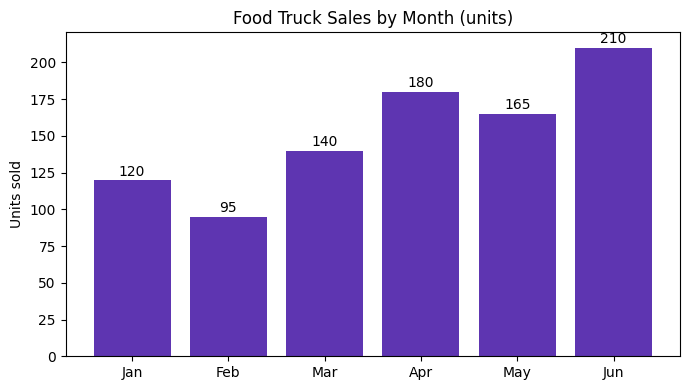

Chart built. Ground truth: {'Jan': 120, 'Feb': 95, 'Mar': 140, 'Apr': 180, 'May': 165, 'Jun': 210}


In [10]:
# RUN AS IS
# Build a bar chart with KNOWN values, save it, and load it as an image.
import matplotlib.pyplot as plt
from PIL import Image

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun"]
sales = [120, 95, 140, 180, 165, 210]   # ground truth, we KNOW these numbers

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(months, sales, color="#5E35B1")
ax.set_title("Food Truck Sales by Month (units)")
ax.set_ylabel("Units sold")
for i, v in enumerate(sales):
    ax.text(i, v + 3, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("sales_chart.png", dpi=110)
plt.show()

chart = Image.open("sales_chart.png").convert("RGB")
print("Chart built. Ground truth:", dict(zip(months, sales)))

In [11]:
# YOUR CODE HERE (Workforce task B)

# TODO: ask the model AT LEAST three questions about the chart and print the
#       answers next to the true values so accuracy is visible. Ideas:
#   1. Which month had the highest sales?
#   2. How many units were sold in March? (Answer with just the number.)
#   3. Did sales go up or down between April and May?
# Tip: ask(chart, your_question)
# Tip: at least one question should require comparing two bars, which is
#      harder than reading one printed number.

questions_and_answers = [("Which month had the lowest sales?", "Feb"),
("How many units were sold in June?", "210"),
("Did sales go up or down between January and February?", "down")]

for q, true_val in questions_and_answers:
    model_answer = ask(chart, q)
    print("Q:", q)
    print("Model says:", model_answer)
    print("True value:", true_val)
    print()

# TODO: your questions here

Q: Which month had the lowest sales?
Model says: Feb.
True value: Feb

Q: How many units were sold in June?
Model says: 210.
True value: 210

Q: Did sales go up or down between January and February?
Model says: Sales went down between January and February.
True value: down



### YOUR ANSWER (Chart reading)

The model answered all three questions I asked it correctly. I would trust it to be **partially** intergrated with a company's finanical board. However, I would not trust it unsupervised and have it's scope limited (to the extent of analysis on collected data). This is mainly due to that business isn't always a proactive stance (which is mostly done internal when its proactive), and many businesses are forced to react when interacting with the external enviornment with a business. Because of this, Finance, unlike accounting, deals with the external side on a greater scale. This can be contributed to many things, however, the main issue lies in one aspect of business: Risk Management. This model would be perfect for analysis of data collected, identifying weak outputs (Sales force with lower Revenue), and even calculating projections based on data, but because Forecasting isn't always accurate, and can sway greatly, it's best to do it.

I would do intergrate it unsupervised in the things I mentioned, but until it has two things: better training and a better system that is proven (company related, think strategic management) that can translate speculation into data, I would be cautious about full implementation.  

## Section 7: YOUR TURN 2, The Hallucination Hunt (Graded, 10 pts)

Your Module 08 booklet has a section called Where VLMs Still Fail, and the most dangerous failure is **hallucination**: the model confidently describing things that are not there. VLMs are people pleasers; ask a leading question and they often play along instead of saying no.

Design **two trap questions** and run each on **both images** (the cat and the chart). A trap question presupposes something false, for example:

* "What color is the dog's collar?" (asked about an image with no dog)
* "What does the sign in the background say?" (no sign exists)
* "Why did sales drop in June?" (they rose)

A model passes the trap by correcting you. It fails by inventing an answer.

In [12]:
# YOUR CODE HERE (Your Turn 2)

# TODO: write two trap questions of your own (do not copy the examples) and
#       run each on BOTH images, printing all four exchanges clearly.
# Tip: the best traps sound casual and confident, exactly like a distracted
#      coworker would ask.

trap_1 = "What color is the door behind the cat?"
trap_2 = "Which office was the lowest in sales on the month of May?"

trap_answer_1 = ask(img, trap_1)
trap_answer_2 = ask(chart, trap_2)

print("Q:", trap_1)
print("A:", trap_answer_1)
print()

print("Q:", trap_2)
print("A:", trap_answer_2)
print()

# TODO: run both traps on img and on chart, print all four Q and A pairs

Q: What color is the door behind the cat?
A: There is no door present in the image; it only features a tiger and snow.

Q: Which office was the lowest in sales on the month of May?
A: Feb.



### YOUR ANSWER (Hallucination report)

*Double click and replace: For each trap, did the model correct you or play along? Why is this failure mode more dangerous in a workplace than simply getting a count wrong? Three or four sentences.*

The model did get a correct answer for the first question: It correctly told me that there was no door behind the cat, and corrected me saying the photo depicts a tiger laying outside in the snow.

The Model in the second question, however, incorrectly falls for the map and answers February. This this in spite of the fact that the chart, and its data contain no information or category relating to offices, just pure sales numbers.

As I mentioned in the last section, this gets dangerous in a workplace because of the concept of Risk Management. This logic can be applied to not only risk management, but across other aspects, such as labs, stuides. When a Model like this is starting to give output on data that doesn't exist, it means it can be taking variables into effect that aren't present. Whether those factors are actually present with a role in data is already dangerous, the issue becomes when this data is then overlooked, and terrible decisions are made because of said interpretation of data.

## Section 8: Preview, The Agent's Eyes (Bridge to Module 09)

**RUN AS IS.** In Module 09 you will build AI agents that perceive, reason, and act. Their perception step is exactly what you have been doing all lab: a VLM answering questions about what it sees. Here is a thirty second preview: we ask the model not just to describe, but to **recommend an action**, which is the seed of the agent loop.

In [14]:
# RUN AS IS
# The same ask() function, but the prompt now requests a decision.
agent_question = (
    "You are a monitoring assistant for a pet daycare. Based on this camera "
    "image, report the situation in one sentence and recommend one action. "
    "Format: SITUATION: ... ACTION: ..."
)
print(ask(img, agent_question))

The tiger is ready for a nap.


Notice what changed: nothing in the model, everything in the prompt. Perception plus a decision format is the doorway to agents. Hold that thought for two weeks.

## Section 9: Try It Yourself, The Deployment Audit (Graded, 20 pts)

This section is fully yours. No scaffolding, no starter code. Your only tools: `ask()`, `show_patches()`, matplotlib, and your judgment.

**The scenario:** You are a junior CV technician. Your manager is considering using a small VLM for one workplace task and asks you to **audit it before anyone trusts it**. You choose the scenario:

* Retail: describing product photos for a store website
* Safety: reporting what is visible on a workplace camera image
* Accessibility: alt text for a community organization's photo library
* Education: describing diagrams or charts for students
* Your own idea (name it clearly)

**Your deliverable, in cells you write yourself:**

1. **The scenario and test set (5 pts):** name your scenario and assemble two or three test images that fit it (upload your own, reuse the chart trick from Section 6 to build controlled test images, or reuse the provided images if they genuinely fit).
2. **The reliability test (5 pts):** design ONE prompt for the task, then test it for consistency by asking the same thing **three different ways** (rephrase it twice) on the same image. A dependable tool gives consistent answers; a fragile one changes its story.
3. **The audit memo (10 pts):** in the answer cell below, write a five to eight sentence memo to your manager: what you tested, what the model got right, what it got wrong or inconsistent, one hallucination risk specific to your scenario, and your verdict: deploy with human review, deploy unsupervised, or do not deploy. Take a position and defend it with your evidence.

**GPU saver:** ten to fifteen questions total is plenty. A sharp audit beats a big one.

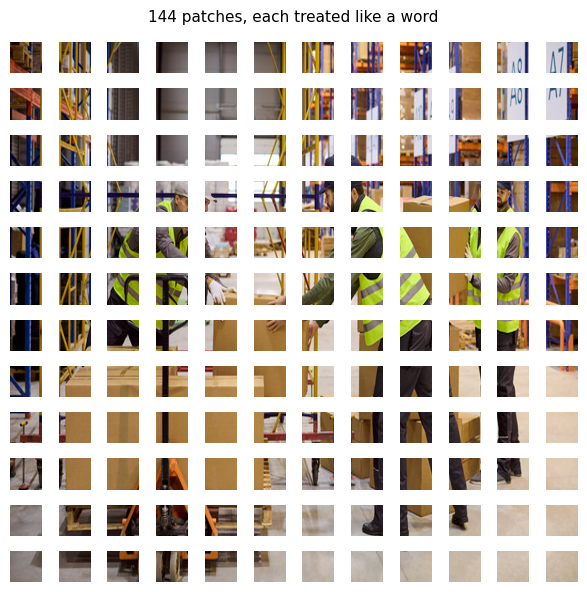

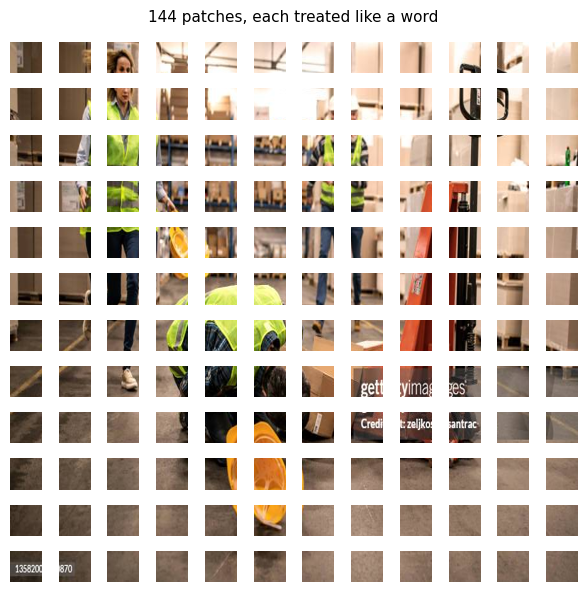

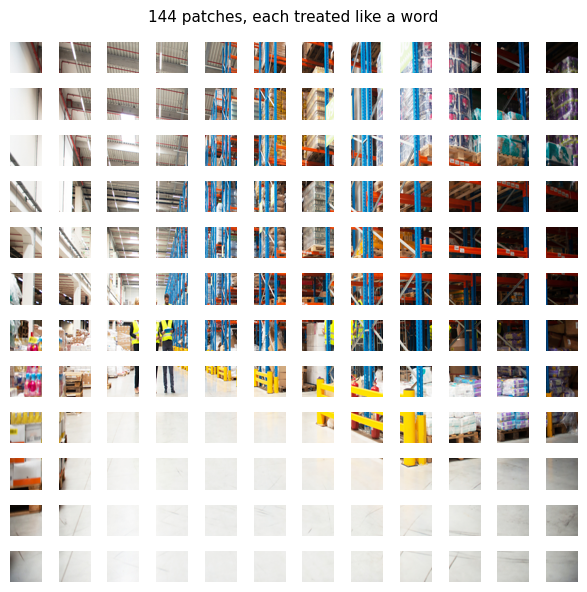

In [15]:
# YOUR CODE HERE (Try It Yourself)
# Build your audit below. Add as many cells as you need.
# Your toolbox:

img4= Image.open("/content/Office_PHOTO_1_ITAL1378.jpg").convert("RGB").resize((384, 384))
img5= Image.open("/content/Office_PHOTO_2_ITAL1378.jpg").convert("RGB").resize((384, 384))
img6= Image.open("/content/Office_PHOTO_3_ITAL1378.jpg").convert("RGB").resize((384, 384))

show_patches(img4, patch_size=32)
show_patches(img5, patch_size=32)
show_patches(img6, patch_size=32)

#   matplotlib and PIL for building controlled test images
# Reminder: print every question next to its answer so your memo's evidence
# is visible in the notebook output.

In [20]:
prompts = {
    "direct":     "Write text for this image similar to a photo caption",
    "rephrase_1": "What is going on in this photo? Describe this image as if you were describing it to a warehouse manager.",
    "rephrase_2": "An OSHA inspector analyzes this photos. Are there any violations would the OSHA inspector identify that are occuring in this photo? ",
}

for name, img in [("img4", img4), ("img5", img5), ("img6", img6)]:
    print(f"=== {name} ===")
    for label, p in prompts.items():
        answer = ask(img, p)
        print(f"[{label}] Q: {p}\n -> {answer}\n")

=== img4 ===
[direct] Q: Write text for this image similar to a photo caption
 -> Ave. A8 A7 signs are above the boxes.

[rephrase_1] Q: What is going on in this photo? Describe this image as if you were describing it to a warehouse manager.
 -> This image depicts a warehouse environment where several warehouse workers are engaged in various tasks. The scene is dominated by a large, open space with a concrete floor. The floor is covered with a light-colored material, possibly concrete or a similar material, which provides a clean and organized appearance.

In the foreground, there are three warehouse workers. They are all wearing safety vests, which are typically green and reflective, indicating that they are working in a hazardous environment. The workers are engaged in various tasks, which include:

1. **Material Handling**: One worker is seen handling a large box, which appears to be a palletized item. This worker is using a pallet jack, a type of mechanical device used to lift and 

### YOUR ANSWER (Audit memo)
Analysis:

I tested this model for the specific purpose of montioring wareshouse regulations and for the potential of implementing this model as a method to ensure warehouse safety in compliance with regulations. I asked the model a quesiton, then phrased it in 2 different ways, one where asking if a warehouse manager saw this, and the other to where an OSHA inspector sees this. Based on my analysis, the feedback for the model's performance is described all images with a list below:

Image 1: The [Model] is able to correctly describe the details in the image. The [Model] correctly identifies the key metric in which a warehouse worker would identify. The [Model] accurcatlely says that the image does not have enough detail to determine violations.

Image 2: The [Model] correctly describes the first prompt, and goes into detail in the second prompt. However, the model fails to elaborate on whether OSHA violations are being committed due to the [Model] saying the image does not have an OSHA inspector present, despite OSHA violations being present (Work is being continued despite a warehouse member being incapacitated).

Image 3: The [Model] is able to correctly identify details in regards to all 3 prompts. It is able to correctly describe details in relation to the 1st prompt, it is able to identify the basic key points in relation to a warehouse manager, and it is able to identify every basic OSHA requirement, in which this photo does show compliance, and the model correctly predicted it.

In my opinion, the [Model] does show potential of being implemented in a warehouse workplace. However, further training is neeeded to identify OSHA requirements and other aspects. It is my recommendation that the [Model] is trained further before being implemented

## Section 10: Reflection Questions (Graded, 20 pts, 2 each)

Answer each question in complete sentences directly in its YOUR ANSWER cell. Short bullet answers will not earn full credit. I want your reasoning in your own words.

**Q1. Patches as words.** Explain to a friend with no AI background how a Vision Transformer reads an image, using the patch grid you made in Section 2. Use your own analogy, not one from this notebook.

### YOUR ANSWER

How I would describe Vision Transformer to a friend is basically if they took a completed puzzle and break the pieces down into sections to show how the pieces fit together. The Vision Transformer breaks down each part of the puzzle that it can read, and then identifies the distinct characteristics that make up that section of the image.

**Q2. The three part architecture.** A VLM has eyes (vision encoder), a translator (projector), and a voice (language model). When your model hallucinated in Section 7, which part do you suspect was most responsible, and why?

### YOUR ANSWER

In my opinion, the part that failed that describes the issue the VLM is vision encoder. For the first prompt (cat), It correctly identifies that a door isn't in a image, but then describes the photo of the tiger. This could be on human error with code, but it manages to identify no door is present. However, for the second question related to sales, the model fails to identify that the category "office" does not exist, and thus says a month instead. Although we could assume the model is making the assumption that the chart is describing all offices. the notion must be met that the office hallucinated the idea of offices being a category.

**Q3. The prompt is the task.** In Section 4 one model did several jobs. What does this mean for how CV teams will be organized in the workplace: fewer specialist models to maintain, or new problems to manage? Name one of each.

### YOUR ANSWER

For CV teams, fewer specialists will be needed due to a decrease in updates, however, the CV teams will need better familiarity across all aspects of the models they use, due to the models having wider ranging tasks and potentially larger and complicated tasks involved. A model that may be implemented into warehouse will have to manage weight disribution on trucks, calculate destinations or "checkpoint" warehouses, and even forecast projections on delivery/shipping. For new problems, the model could potentially crash completely if tasks are over implemented into the model, causing disater in a work place.

**Q4. Constrained outputs.** Why does "answer with just a number" matter so much when a VLM is wired into software instead of chatting with a person? Give a concrete example of what breaks without it.

### YOUR ANSWER

Answer with just a number matters greatly in this instance because if the model is hooked up to a software, it can pull data from the said software/server it is hooked up to, comparing to chatting with a person.

For example, say a VLM is hooked up to a company's marketing department's data. All the VLM has to do when it comes to say, client intake in a month, is pull the data from the marketing department's reports to find the number, with it being accurately displayed, and the VLM isn't forced to either guess or calculate to determine the answer. Comparing it with chatting a person, the model could break if the model is tasked to market because the model is being required to complete a task in which enough data may be lacking to where the model is forced to resort to other means to deliver results.


**Q5. Small versus frontier.** You used a 500 million parameter open model today; Module 08 covered frontier models thousands of times larger. Name two workplace situations where the small local model is the RIGHT choice even though it is weaker.

### YOUR ANSWER

*Double click and replace this text with your answer in complete sentences.*

There are two workplace situations in which a small local model is much better then using a larger market. One would be inventory logging. Assuming the company already has an accurate/effecient inventory system, all the model has to do is log the inventory by the next number or classification. The other best part a smaller network is able to use would be printing an entire report in which **ALL** data is presented to it, the model just needs to scan the file and fill in the chart itself.

**Q6. Alt text ethics.** Who is harmed when auto generated alt text is wrong, and why is "a human reviews every caption" easier to promise than to deliver at the scale of a real website?

### YOUR ANSWER

The people who are harmed when auto generated alt text is everyone directly involed, and those who may rely on said text. All the people the incorrect texts passes through without review or misidentifying the issues will then go off that said data. Once that data gets published, everyone who relies on data and reviews from those overseeing the model is then greatly effective.

For example, using a website, if a news article misidentifes someone in a picture, the person who is misidentified could be compromoised, the original writer, the editor, and publisher are now taking the blow, and those who work at the company and those who are in relation in the photo are now in jeporady of catching unnessary liability.

**Q7. Ground truth.** In Section 6 you built the chart yourself so you knew the true numbers. Why is this a professional habit, and what goes wrong when teams evaluate AI tools on data where nobody knows the right answers?

### YOUR ANSWER

It is important to build it yourself because no matter how much the data get's right, new data can always be misinterpreted. When teams evaluate AI tools' performance, and they don't know whether answers are correct, this creates the issue that no one would actually know if the AI tools is performing as intended.

**Q8. Hallucination versus error.** Using your Section 7 results, explain the difference between a model being wrong and a model hallucinating. Why is the second one harder to catch in a busy workplace?

### YOUR ANSWER

The difference a model is wrong, usually, there are larger signs the model is wrong, and including confirmation bias, if one doesn't trust the model, the model's wrong answers have a higher chance of being noticed. With hallucinating, the model may be trying to confirm the person's observations despite them not being correct. This creates the issue because the person montioring the model may be negligent to actually identify a halluncation.

**Q9. The audit mindset.** Your Try It Yourself verdict required taking a position. What evidence would have changed your verdict to the opposite one? Being able to answer this is what separates an audit from an opinion.

### YOUR ANSWER

Evidence that would have changed my mindset in this scenario would be if the model failed to actually go into detail and gave vague answers. I chose the warehouse scenario because there are alot of OSHA regulations that are universal in the way they are enforced, and how they are defined. THis allowed me to use something a model could identify key aspects without having to use extra programs or enhancing the image. If the model never went into detail, it would have been an extreme liability to ever try to implement this model in a real life warehouse scenario.

**Q10. Changed mind.** Before this lab, what did you believe about how AI understands images that turned out to be wrong or incomplete? Be specific about which section changed your mind.

### YOUR ANSWER

Running through these labs, I have learned to pick up on some ways and some issues AI has when it comes to understanding images. However, one I kind of didn't noticed was the issue when AI tools at times may blantantly go off of memory and give an answer to something I never asked for. As stated in that question, it could be the result of human error, however, it does show AI has the ability to me negligent at times and completely disregard an image and instead refer to a previous memory (a previous image). This gave me the impression that during training of models, its extremely improtant to watch how the training models' enviornment can affect the model, even if the model and algorithm is built correctly.

## Section 11: Optional Bonus Challenges (up to +20)

Each completed challenge earns 5 bonus points. Pick any, all, or none. All four are light on compute.

**Bonus A, The tiny sibling (+5):** Load `HuggingFaceTB/SmolVLM-256M-Instruct` (half the size, a fast extra download) and rerun your three Your Turn 1 questions on it. In one or two sentences: what did shrinking the model cost?

**Bonus B, The receipt reader (+5):** Using PIL, draw your own fake receipt image (store name, three items with prices, a total) with `ImageDraw.text`, then ask the model to extract the total and one item price. You know the ground truth because you drew it.

**Bonus C, The patch size probe (+5):** Take one image with small important detail (text or a small object). Show its patch grid at 96 pixels, then ask the model a question about that small detail. Connect what you see in the grid to how the model answered, in one or two sentences.

**Bonus D, Your own photo set (+5):** Complete your Try It Yourself audit entirely with photos you took yourself. If you already did, say so here and point to the cells.

In [ ]:
# YOUR CODE HERE (Optional bonus work)
# Label each attempt clearly with a comment: # BONUS A, # BONUS B, etc.
# Memory tip for Bonus A: load the 256M model AFTER you finish everything
# else, and if memory complains, run:
#   del model; import gc; gc.collect(); torch.cuda.empty_cache()
# before loading the smaller one.

## Section 12: Submission Checklist

1. Choose Runtime, then Run all, one final time. Confirm there are no errors and every question and answer pair is visible.
2. Check that every **YOUR ANSWER** cell has your words in it (search the notebook for the word "replace" to find any you missed).
3. File, Download, Download .ipynb, **with all outputs visible**. Do not clear outputs.
4. Name it **L08_LastName_FirstName_ITAI1378.ipynb** and submit the notebook to Canvas. The notebook is the only deliverable.

Today you interviewed images, made one model wear five hats, caught it lying, and wrote a professional audit, all on a model small enough to run on a laptop. In Module 09 the VLM you just tamed becomes the **eyes of an agent** that perceives, reasons, and acts. You already wrote its first perception prompt in Section 8.

*Email or message me if you have any questions.*